# "MNIST: Distinguishing Threes from Sevens"
> Using Fastai to classify threes and sevens from the MNIST dataset.

- toc: true
- badges: true
- comments: true
- categories: [fastai, jupyter]

# Introduction

I am following along with Chapter 4 of {% cite fastbook2020 %}.

In [1]:
from fastai.vision.all import *

In [2]:
#collapse-output
path = untar_data(URLs.MNIST_SAMPLE)

So what got downloaded?

In [3]:
path.ls()

(#3) [Path('/data/kaushik/.fastai/data/mnist_sample/valid'),Path('/data/kaushik/.fastai/data/mnist_sample/train'),Path('/data/kaushik/.fastai/data/mnist_sample/labels.csv')]

That huge path is a pain to look at. Let's shorten it by setting the BASE_PATH.

In [4]:
Path.BASE_PATH = path
path.ls()

(#3) [Path('valid'),Path('train'),Path('labels.csv')]

What do we have under train?

In [5]:
(path/'train').ls()

(#2) [Path('train/3'),Path('train/7')]

What do we have under the 7?

In [6]:
(path/'train'/'7').ls().sorted()

(#6265) [Path('train/7/10002.png'),Path('train/7/1001.png'),Path('train/7/10014.png'),Path('train/7/10019.png'),Path('train/7/10039.png'),Path('train/7/10046.png'),Path('train/7/10050.png'),Path('train/7/10063.png'),Path('train/7/10077.png'),Path('train/7/10086.png')...]

We have 6,265 images of sevens. Look at one using the PIL library.

In [7]:
Image.open((path/'train'/'7').ls().sorted()[0])

In [8]:
seven_tensors = [tensor(Image.open(pic_pat)).float()/255. for pic_path in (path/'train'/'7').ls().sorted()]
three_tensors = [tensor(Image.open(pic_path)).float()/255. for pic_path in (path/'train'/'3').ls().sorted()]
len(seven_tensors), len(three_tensors)

(6265, 6131)

Use Fastai convenience function _show_image_ to display the tensor

<AxesSubplot:>

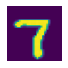

In [9]:
show_image(seven_tensors[0])

In [10]:
stacked_sevens = torch.stack(seven_tensors)
stacked_threes = torch.stack(three_tensors)
stacked_sevens.shape, stacked_threes.shape

(torch.Size([6265, 28, 28]), torch.Size([6131, 28, 28]))

Assemble the training data. Each input will be a vector of 784 values.

In [11]:
train_x = torch.cat([stacked_threes, stacked_sevens]).view(-1,28*28)
train_y = tensor([1]*len(three_tensors) + [0]*len(seven_tensors)).unsqueeze(1)
train_x.shape, train_y.shape

torch.Size([12396, 784])

Assemble the validation data

In [15]:
valid_7_tensors = torch.stack([tensor(Image.open(pic_path)).float()/255. for pic_path in (path/'valid'/'7').ls().sorted()])
valid_3_tensors = torch.stack([tensor(Image.open(pic_path)).float()/255. for pic_path in (path/'valid'/'3').ls().sorted()])
valid_7_tensors.shape, valid_3_tensors.shape

(torch.Size([1028, 28, 28]), torch.Size([1010, 28, 28]))

In [16]:
valid_x = torch.cat([valid_3_tensors, valid_7_tensors]).view(-1,28*28)
valid_y = tensor([1]*len(valid_3_tensors) + [0]*len(valid_7_tensors)).unsqueeze(1)
valid_x.shape, valid_y.shape

(torch.Size([2038, 784]), torch.Size([2038, 1]))